# 04 — Active Learning Sampling (Kernel Uncertainty)

Greedy maximum-uncertainty selection in the normalized composition space.
No property values are used.

**Algorithm outline**

1. Represent each composition as `[x_CO2, z_H2, ..., z_H2S]`
   where `z_i = x_i / (1 - x_CO2)` separates CO2 level from impurity pattern.
2. Min-max scale all coordinates to `[0, 1]`.
3. Set RBF length scale to the median nearest-neighbour distance in scaled space.
4. Initialise with a small random seed set `S`.
5. Greedy loop: add the pool point with the highest GP predictive variance given `S`.
6. Save selected compositions at each budget checkpoint.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from thermoift.rng_utils import get_rng

In [2]:
POOL_PATH     = Path('AL_POOL/composition_pool.csv')
OUTPUT_DIR    = Path('AL_Sampling')
IMPURITY_COLS = ['H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']

BUDGETS      = [20, 40, 60, 80, 100]
N_INIT_SEEDS = 2
BASE_SEED    = 770077
RNG_TYPE     = 'PCG64'

SIGMA_F2     = 1.0    # RBF signal variance
SIGMA_N2     = 1e-8   # numerical jitter
L_MULTIPLIER = 5      # l = L_MULTIPLIER * median_NN_distance  (tune after comparison cell)

pool = pd.read_csv(POOL_PATH)
print(f'Pool: {len(pool):,} compositions')
OUTPUT_DIR.mkdir(exist_ok=True)

Pool: 1,000 compositions


In [3]:
# Step 1: Build composition coordinates
# x_CO2 captures the total CO2 level
# z_i = x_i / (1 - x_CO2) captures the impurity pattern (sums to 1 per row)
co2     = pool['CO2'].values
x_total = 1.0 - co2

Z_imp = pool[IMPURITY_COLS].values / np.clip(x_total.reshape(-1, 1), 1e-12, None)

# Feature vector: [x_CO2, z_H2, z_Ar, z_N2, z_CH4, z_O2, z_CO, z_H2S]
X_raw = np.hstack([co2.reshape(-1, 1), Z_imp])
print(f'Feature matrix: {X_raw.shape}  (N_pool x 8)')

Feature matrix: (1000, 8)  (N_pool x 8)


In [4]:
# Step 2: Min-max scaling
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Scaled range: [{X_scaled.min():.4f}, {X_scaled.max():.4f}]')

Scaled range: [0.0000, 1.0000]


In [5]:
# Step 3: Estimate RBF length scale from pool geometry
nbrs     = NearestNeighbors(n_neighbors=2, algorithm='auto').fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
nn_dists = dists[:, 1]             # column 0 = self (dist=0); column 1 = true NN
l_nn     = float(np.median(nn_dists))
l_scale  = L_MULTIPLIER * l_nn    # final length scale used in the AL loop
print(f'Median NN distance (scaled space): {l_nn:.6f}')
print(f'Multiplier: {L_MULTIPLIER}x  ->  l_scale = {l_scale:.6f}')

Median NN distance (scaled space): 0.145215
Multiplier: 5x  ->  l_scale = 0.726075


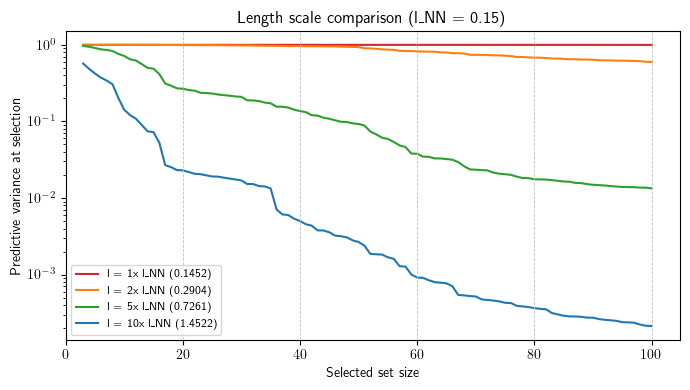

Current L_MULTIPLIER = 5  (change in config cell and re-run to update l_scale)


In [6]:
# Diagnostic: compare uncertainty-decay curves for 1×, 2×, 5×, 10× median NN distance.
# A flat curve means l is too small — the kernel sees only immediate neighbours.
L_MULTS  = [1, 2, 5, 10]
_colors  = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
_n_steps = max(BUDGETS) - N_INIT_SEEDS

def _run_al(l_val):
    '''Greedy AL loop with fixed length scale l_val. Returns list of (S_size, sigma2).'''
    rng_d = get_rng(seed=BASE_SEED, rng_type=RNG_TYPE)
    S = sorted(rng_d.choice(len(X_scaled), size=N_INIT_SEEDS, replace=False).tolist())
    P = [i for i in range(len(X_scaled)) if i not in set(S)]
    log   = []
    denom = 2.0 * l_val**2
    for _ in range(_n_steps):
        X_S   = X_scaled[S]
        X_P   = X_scaled[P]
        sq_SS = np.sum((X_S[:, None, :] - X_S[None, :, :])**2, axis=-1)
        sq_PS = np.sum((X_P[:, None, :] - X_S[None, :, :])**2, axis=-1)
        K_SS  = SIGMA_F2 * np.exp(-sq_SS / denom) + SIGMA_N2 * np.eye(len(S))
        K_PS  = SIGMA_F2 * np.exp(-sq_PS / denom)
        L_ch  = np.linalg.cholesky(K_SS)
        alpha = np.linalg.solve(L_ch, K_PS.T)
        var   = np.clip(SIGMA_F2 - np.sum(alpha**2, axis=0), 0.0, None)
        best  = int(np.argmax(var))
        S.append(P[best])
        del P[best]
        log.append((len(S), float(var[best])))
    return log

fig, ax = plt.subplots(figsize=(7, 4))
for mult, color in zip(L_MULTS, _colors):
    l_val = mult * l_nn
    log   = _run_al(l_val)
    sizes = [s for s, _ in log]
    vals  = [v for _, v in log]
    ax.semilogy(sizes, vals, lw=1.5, color=color, label=f'l = {mult}x l_NN  ({l_val:.4f})')

for b in BUDGETS:
    ax.axvline(b, ls='--', lw=0.6, color='silver')
ax.set_xlabel('Selected set size')
ax.set_ylabel('Predictive variance at selection')
ax.set_title(f'Length scale comparison  (l_NN = {l_nn:.2f})')
ax.legend(fontsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ls_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Current L_MULTIPLIER = {L_MULTIPLIER}  (change in config cell and re-run to update l_scale)')

In [7]:
# Step 4: RBF kernel
# k(a,b) = sigma_f^2 * exp( -||a-b||^2 / (2*l^2) )
def rbf_kernel(A, B):
    '''A:(n,d), B:(m,d) -> kernel matrix (n,m).'''
    diff = A[:, None, :] - B[None, :, :]   # (n, m, d)
    sq   = np.sum(diff**2, axis=-1)         # (n, m)
    return SIGMA_F2 * np.exp(-sq / (2.0 * l_scale**2))

In [8]:
# Steps 5-8: Initial seed set + greedy AL loop
rng = get_rng(seed=BASE_SEED, rng_type=RNG_TYPE)

seed_pool_idx = sorted(rng.choice(len(pool), size=N_INIT_SEEDS, replace=False).tolist())
S_idx = list(seed_pool_idx)
P_idx = [i for i in range(len(pool)) if i not in set(S_idx)]
print(f'Initial seeds (pool indices): {S_idx}')

selection_log = []
budgets_set   = set(BUDGETS)
max_budget    = max(BUDGETS)
n_steps       = max_budget - N_INIT_SEEDS

print(f'Running greedy AL for {n_steps} steps ...')
print()

for step in range(n_steps):
    X_S = X_scaled[S_idx]   # (|S|, d)
    X_P = X_scaled[P_idx]   # (|P|, d)

    # Gram matrix of selected set (with numerical jitter)
    K_SS = rbf_kernel(X_S, X_S) + SIGMA_N2 * np.eye(len(S_idx))

    # Cross-covariance: pool candidates vs selected set
    K_PS = rbf_kernel(X_P, X_S)   # (|P|, |S|)

    # Predictive variance via Cholesky:
    # var(x*) = sigma_f^2 - || L^{-1} k(X_S, x*) ||^2
    L     = np.linalg.cholesky(K_SS)
    alpha = np.linalg.solve(L, K_PS.T)                               # (|S|, |P|)
    var   = np.clip(SIGMA_F2 - np.sum(alpha**2, axis=0), 0.0, None)  # (|P|,)

    best_local    = int(np.argmax(var))
    best_pool_idx = P_idx[best_local]
    best_var      = float(var[best_local])

    S_idx.append(best_pool_idx)
    del P_idx[best_local]

    selection_log.append({'S_size': len(S_idx), 'pool_idx': best_pool_idx, 'sigma2': best_var})

    if len(S_idx) in budgets_set:
        n = len(S_idx)
        df_out = pool.iloc[S_idx].copy().reset_index(drop=True)
        df_out.insert(0, 'pool_idx', S_idx)
        df_out.to_csv(OUTPUT_DIR / f'N{n:03d}_al.csv', index=False)
        print(f'  [N={n:3d}]  saved   sigma^2 = {best_var:.4e}')

print()
print(f'Done.  Selected set size: {len(S_idx)}')

Initial seeds (pool indices): [259, 377]
Running greedy AL for 98 steps ...

  [N= 20]  saved   sigma^2 = 2.6769e-01
  [N= 40]  saved   sigma^2 = 1.3651e-01
  [N= 60]  saved   sigma^2 = 3.7823e-02
  [N= 80]  saved   sigma^2 = 1.7618e-02
  [N=100]  saved   sigma^2 = 1.3385e-02

Done.  Selected set size: 100


In [9]:
# Step 9: Save selection log
log_df = pd.DataFrame(selection_log)
log_df.to_csv(OUTPUT_DIR / 'selection_log.csv', index=False)
print(f'Selection log ({len(log_df)} steps) -> {OUTPUT_DIR}/selection_log.csv')
print(log_df.head())

Selection log (98 steps) -> AL_Sampling/selection_log.csv
   S_size  pool_idx    sigma2
0       3       936  0.966544
1       4       310  0.944371
2       5       203  0.910846
3       6       567  0.873929
4       7       152  0.856776


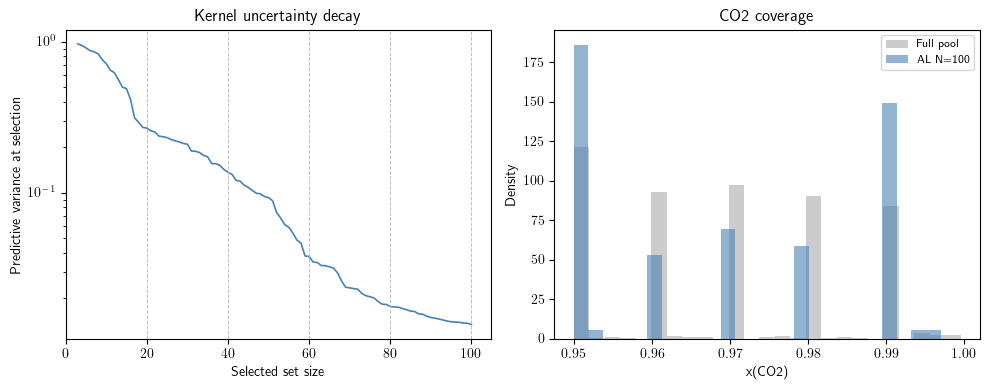

Figure saved: AL_Sampling/al_summary.png


In [10]:
# Step 10: Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: uncertainty decay over greedy steps
ax = axes[0]
ax.semilogy(log_df['S_size'], log_df['sigma2'], lw=1.2, color='steelblue')
for b in BUDGETS:
    ax.axvline(b, ls='--', lw=0.7, color='silver')
ax.set_xlabel('Selected set size')
ax.set_ylabel('Predictive variance at selection')
ax.set_title('Kernel uncertainty decay')
ax.set_xlim(left=0)

# Right: CO2 distribution pool vs final AL selection
ax = axes[1]
ax.hist(pool['CO2'], bins=25, density=True, alpha=0.4, color='gray', label='Full pool')
ax.hist(pool.iloc[S_idx]['CO2'], bins=25, density=True, alpha=0.6, color='steelblue',
        label=f'AL  N={max_budget}')
ax.set_xlabel('x(CO2)')
ax.set_ylabel('Density')
ax.set_title('CO2 coverage')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'al_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {OUTPUT_DIR}/al_summary.png')